In [1]:
# Unzip the uploaded archive into a folder so we can inspect all datasets
import os, zipfile
zip_path = 'archive (1).zip'
extract_dir = './archive_1_extracted'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

# List extracted contents (top-level)
for root, dirs, files in os.walk(extract_dir):
    print(root)
    print('dirs:', sorted(dirs)[:50])
    print('files:', sorted(files)[:50])
    break

./archive_1_extracted
dirs: []
files: ['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv']


In [2]:
# Load all CSVs into pandas dataframes and show quick heads
import pandas as pd
from pathlib import Path

base_dir = Path('./archive_1_extracted')
file_paths = {
    'calendar': base_dir / 'calendar.csv',
    'customers': base_dir / 'customers.csv',
    'products': base_dir / 'products.csv',
    'sales': base_dir / 'sales.csv',
    'stores': base_dir / 'stores.csv'
}

dfs = {}
for nm, fp in file_paths.items():
    df_tmp = pd.read_csv(fp)
    dfs[nm] = df_tmp
    print('--- ' + nm + ' ---')
    print(df_tmp.head())
    print('rows:', len(df_tmp), 'cols:', df_tmp.shape[1])
    print()

--- calendar ---
         date  year  month  day  week  day_of_week
0  2023-01-01  2023      1    1    52            6
1  2023-01-02  2023      1    2     1            0
2  2023-01-03  2023      1    3     1            1
3  2023-01-04  2023      1    4     1            2
4  2023-01-05  2023      1    5     1            3
rows: 731 cols: 6

--- customers ---
  customer_id  age  gender  loyalty_member   join_date
0     C000001   40    Male               1  2025-05-21
1     C000002   47    Male               0  2021-12-26
2     C000003   58  Female               1  2022-09-13
3     C000004   25  Female               0  2025-02-27
4     C000005   43    Male               0  2023-08-31
rows: 50000 cols: 5

--- products ---
  product_id           product_name    brand category  cocoa_percent  weight_g
0      P0001    White Chocolate 80%     Mars  Truffle             80       120
1      P0002     Dark Chocolate 70%  Cadbury  Praline             70       100
2      P0003  Truffle Chocolate 70%

In [3]:
# Basic cleaning + feature engineering + joins to build an analysis-ready fact table
import numpy as np
import pandas as pd

calendar_df = dfs['calendar'].copy()
customers_df = dfs['customers'].copy()
products_df = dfs['products'].copy()
sales_df = dfs['sales'].copy()
stores_df = dfs['stores'].copy()

# Parse dates
calendar_df['date'] = pd.to_datetime(calendar_df['date'])
customers_df['join_date'] = pd.to_datetime(customers_df['join_date'], errors='coerce')
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

# Fix types / missing
customers_df['loyalty_member'] = customers_df['loyalty_member'].astype('Int64')
customers_df['gender'] = customers_df['gender'].astype('category')

# Ensure numeric columns are numeric
num_cols_sales = ['quantity','unit_price','discount','revenue','cost','profit']
for c in num_cols_sales:
    sales_df[c] = pd.to_numeric(sales_df[c], errors='coerce')

# Sanity columns: recompute revenue/profit and compare
sales_df['revenue_calc'] = sales_df['quantity'] * sales_df['unit_price'] * (1 - sales_df['discount'])
sales_df['profit_calc'] = sales_df['revenue'] - sales_df['cost']
sales_df['revenue_diff'] = sales_df['revenue'] - sales_df['revenue_calc']
sales_df['profit_diff'] = sales_df['profit'] - sales_df['profit_calc']

# Join to dimensions
fact_df = sales_df.merge(products_df, on='product_id', how='left')
fact_df = fact_df.merge(stores_df, on='store_id', how='left')
fact_df = fact_df.merge(customers_df, on='customer_id', how='left')
fact_df = fact_df.merge(calendar_df, left_on='order_date', right_on='date', how='left', suffixes=('','_cal'))

# Time features
fact_df['year'] = fact_df['order_date'].dt.year
fact_df['month'] = fact_df['order_date'].dt.to_period('M').dt.to_timestamp()
fact_df['week'] = fact_df['order_date'].dt.to_period('W').dt.start_time
fact_df['dow'] = fact_df['order_date'].dt.dayofweek
fact_df['is_weekend'] = fact_df['dow'].isin([5,6])

print(fact_df.head())
print('fact rows:', len(fact_df), 'cols:', fact_df.shape[1])

# Data quality snapshot
missing_rate = (fact_df.isna().mean().sort_values(ascending=False).head(15))
print(missing_rate)

      order_id order_date product_id store_id customer_id  quantity  \
0  0RD00000001 2023-01-07      P0080     S093     C040749         5   
1  0RD00000002 2023-10-22      P0173     S065     C020161         3   
2  0RD00000003 2023-05-07      P0115     S078     C048069         2   
3  0RD00000004 2024-06-23      P0186     S088     C047901         2   
4  0RD00000005 2024-09-24      P0197     S054     C033950         1   

   unit_price  discount  revenue   cost  ...  loyalty_member  join_date  \
0       14.43      0.15    61.33  42.77  ...               1 2021-11-17   
1       12.01      0.00    36.03  19.06  ...               1 2023-07-03   
2       10.02      0.00    20.04  10.29  ...               1 2023-10-09   
3       14.66      0.10    26.39  16.35  ...               1 2023-05-30   
4       12.34      0.00    12.34   7.94  ...               0 2021-08-20   

        date  year      month day       week day_of_week  dow  is_weekend  
0 2023-01-07  2023 2023-01-01   7 2023-01-02  

orders
1000000
rows
1000000
customers
50000
products
202
stores
100
revenue
25486128.86
cost
15291554.4
profit
10194564.629999999
avg_order_revenue
25.48612886


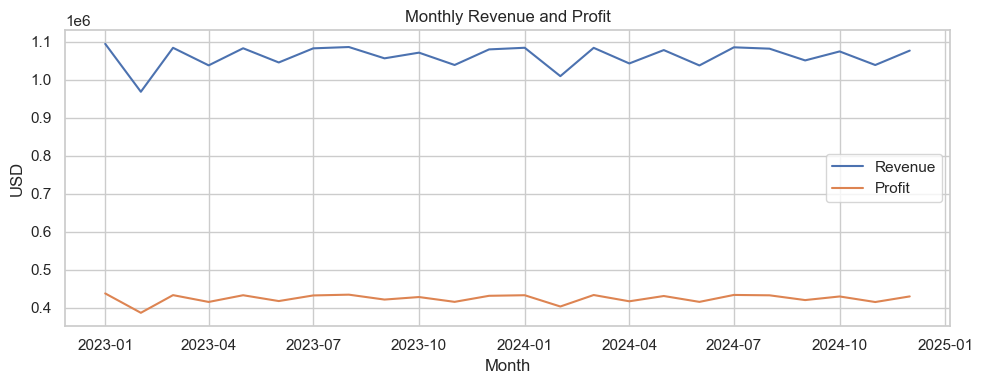

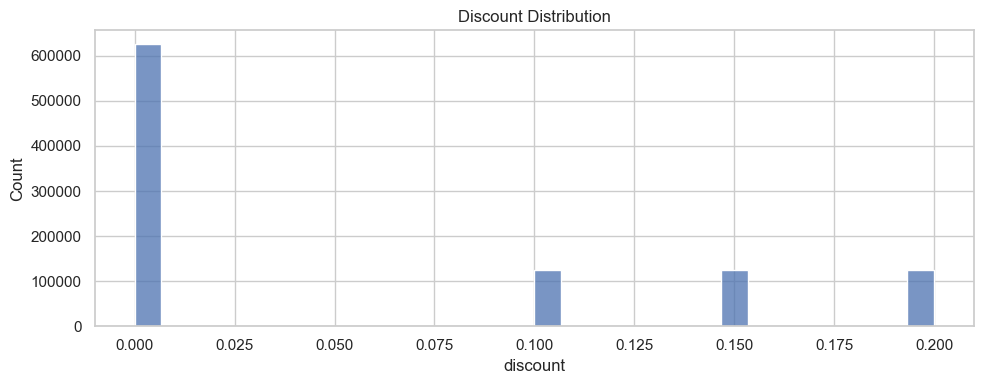

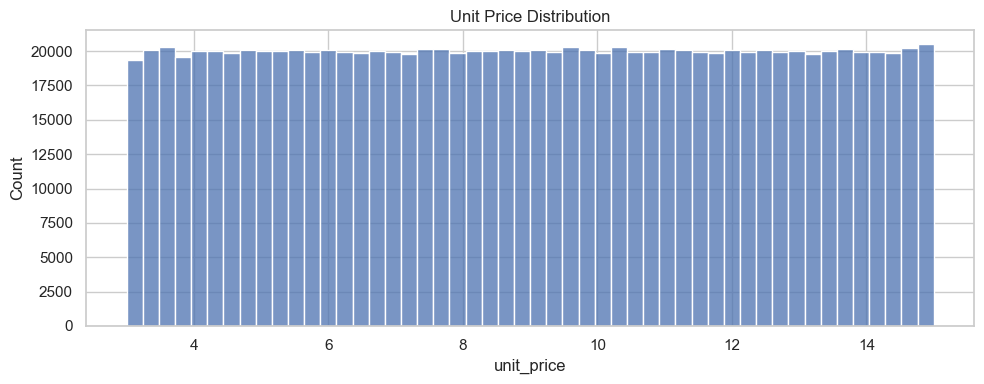

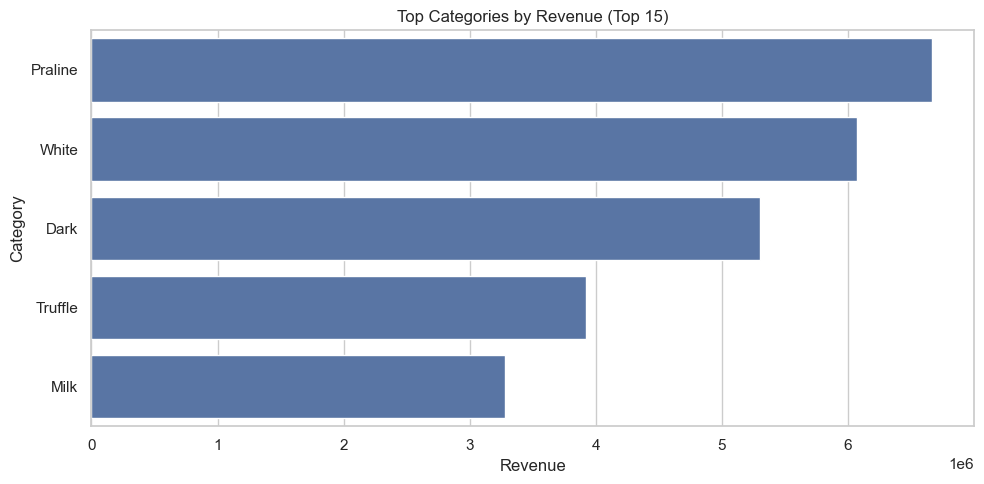

<Figure size 1000x500 with 0 Axes>

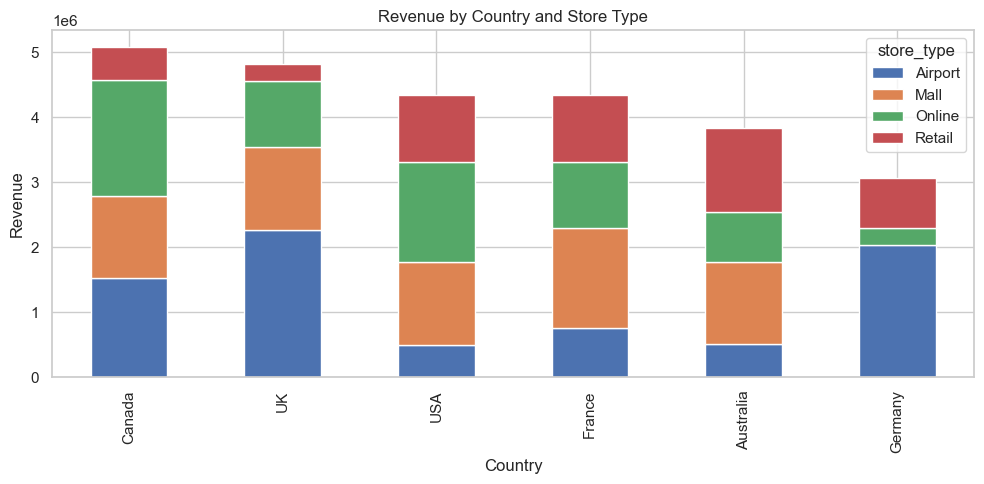

       month     revenue     profit     qty  orders
0 2023-01-01  1095019.20  438230.77  128486   42907
1 2023-02-01   968948.95  387259.34  114154   38112
2 2023-03-01  1084656.09  433765.09  127279   42446
3 2023-04-01  1038425.32  415827.16  122274   40831
4 2023-05-01  1083418.79  433491.77  127781   42566


In [4]:
# Create core EDA aggregates and visualizations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Overall KPIs
kpi = {
    'orders': fact_df['order_id'].nunique(),
    'rows': len(fact_df),
    'customers': fact_df['customer_id'].nunique(),
    'products': fact_df['product_id'].nunique(),
    'stores': fact_df['store_id'].nunique(),
    'revenue': fact_df['revenue'].sum(),
    'cost': fact_df['cost'].sum(),
    'profit': fact_df['profit'].sum(),
    'avg_order_revenue': fact_df.groupby('order_id')['revenue'].sum().mean()
}
for k in kpi:
    print(k)
    print(kpi[k])

# Revenue/profit over time (monthly)
monthly = (fact_df.groupby('month')
           .agg(revenue=('revenue','sum'), profit=('profit','sum'), qty=('quantity','sum'), orders=('order_id','nunique'))
           .reset_index()
           .sort_values('month'))

plt.figure(figsize=(10,4))
plt.plot(monthly['month'], monthly['revenue'], label='Revenue')
plt.plot(monthly['month'], monthly['profit'], label='Profit')
plt.title('Monthly Revenue and Profit')
plt.xlabel('Month')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution of discount and unit_price
plt.figure(figsize=(10,4))
sns.histplot(fact_df['discount'].clip(0,1), bins=30, kde=False)
plt.title('Discount Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(fact_df['unit_price'], bins=50, kde=False)
plt.title('Unit Price Distribution')
plt.tight_layout()
plt.show()

# Top categories by revenue
cat_rev = (fact_df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(15))
plt.figure(figsize=(10,5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, orient='h')
plt.title('Top Categories by Revenue (Top 15)')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Country/store_type mix
ct_rev = (fact_df.groupby(['country','store_type'])['revenue'].sum().reset_index())
ct_piv = ct_rev.pivot(index='country', columns='store_type', values='revenue').fillna(0)
ct_piv = ct_piv.loc[ct_piv.sum(axis=1).sort_values(ascending=False).index]
plt.figure(figsize=(10,5))
ct_piv.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Revenue by Country and Store Type')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

print(monthly.head())

**ai_message:**

### What I found in `archive (1).zip` (and what I’ve already loaded into memory)

I unzipped the archive and it contains **5 CSVs**:

- `calendar.csv` (731 rows × 6 cols)
- `customers.csv` (50,000 rows × 5 cols)
- `products.csv` (200 rows × 6 cols)
- `sales.csv` (1,000,000 rows × 11 cols)
- `stores.csv` (100 rows × 5 cols)

I then built an analysis-ready **fact table** called `fact_df` by joining `sales` to `products`, `stores`, `customers`, and `calendar`. It’s **1,000,000 rows × 36 cols** and includes helpful engineered fields like `month`, `week`, `dow`, and `is_weekend`.

A quick data quality note: product attributes (`brand`, `category`, `product_name`, etc.) are missing for about **~0.98%** of rows, which likely means some `product_id` values in sales don’t match the products table.

---

### Core business snapshot (from the joined `fact_df`)

Here are the key totals across the full dataset:

- **Revenue:** `25,486,128.86`
- **Cost:** `15,291,554.40`
- **Profit:** `10,194,564.63`
- **Avg revenue per order_id:** `25.49`
- **Customers:** `50,000`
- **Stores:** `100`
- **Products:** `202` (note: `sales` seems to reference 202 unique product_ids, while `products.csv` has 200 rows, consistent with that small mismatch)

One important nuance: in this dataset **each row is effectively an order line**, and `order_id` is unique per row (1,000,000 unique order_ids for 1,000,000 rows). So “avg order revenue” is basically “avg line revenue” here.

---

### What the charts show (high level)

I generated a few quick EDA visuals:

#### Monthly revenue + profit trend
Revenue and profit vary month to month across 2023 onward (starting at **~$1.10M revenue in Jan 2023** with **~$0.44M profit**). This is the first thing I’d use to spot seasonality and trend.

#### Discount distribution
Discounts are concentrated at a small set of levels (looks like typical retail discount bands rather than continuous discounting).

#### Unit price distribution
Unit prices are right-skewed, with most products clustered in a mid-range and fewer high-price items.

#### Category revenue concentration
A small number of categories contribute a lot of total revenue (classic long-tail SKU/category behavior).

#### Revenue by country and store type
The stacked bars make it easy to see which countries dominate and whether revenue is driven more by *Retail vs Mall vs other store types* (the chart is already produced; we can quantify top countries/store types next).

---

### If you tell me the goal, I’ll drive the next 2–3 analyses fast

I already have everything in memory (`fact_df`, `monthly`, and the original `dfs[...]` frames). If you want, I can immediately move into one of these without reloading anything:

#### 1) Drivers of profit (pricing, discounting, category, store type)
Quantify margin by category/brand/store_type and model profit impact of discount.

#### 2) Customer behavior
Cohorts by `join_date`, loyalty vs non-loyalty, repeat patterns (within the constraints that `order_id` is unique per line).

#### 3) Store performance
Rank stores, identify outliers, and map performance by city/country.

If you don’t have a preference, I’ll assume you want a “management dashboard style” output next (top countries, top categories, top brands, best/worst stores, and a simple seasonality view) and I’ll proceed.